### Particle tracking experiments: Southeast Indian Ridge (SEIR) - Macquarie Ridge (MR)

In [12]:
from parcels import FieldSet, JITParticle, ParticleSet, Variable 
from parcels import AdvectionRK4

In [13]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [14]:
import os
import matplotlib.pyplot as plt 
import numpy as np
import zarr
import xarray as xr
from xgcm import Grid
import cmocean
import warnings
from datetime import datetime, timedelta
import matplotlib as mpl
import gsw
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors

In [15]:
%matplotlib inline
plt.rcParams['font.size'] = '12'
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [16]:
workingdir = '/g/data/jk72/mj0995'
os.chdir(workingdir) 

import functions as func
from functions import DeleteErrorParticle, SampleTS, SampleUV, StuckParticles

In [17]:
savepath = os.path.join(workingdir, 'figures')

In [18]:
# import imp 
# imp.reload(func)

#### Load sea surface height field (absolute dynamic topography, ADT)

In [19]:
ssh_insitu = xr.open_dataset('data/cmems_adt_MR.nc')

#### Load bathymetry dataset

In [20]:
bathy = xr.open_dataset('data/circumpolar_bathy_GEBCO2024.nc')
bathy['depth'] = bathy.elevation*-1
new_bathy = bathy.coarsen(lon=10).mean().coarsen(lat=10).mean()

#### Circumpolar datasets

In [21]:
### Mean dynamic topography (Aviso: MDT-CNES-CLS22)
circumpolar_mdt = xr.open_dataset('data/circumpolar_mdt.nc')

In [22]:
### Eddy kinetic energy: 10-year (2010-2020) average EKE, calculated annually from satellite geostrophic velocities.
circumpolar_eke = xr.open_dataset('data/circumpolar_eke_mean.nc').__xarray_dataarray_variable__

In [23]:
# ssh = xr.open_dataset('/g/data/v45/jw2777/Scripts/Watermass_thoughts/circumpolar_ssh_monthly.nc')

In [24]:
# circumpolar_ssh_std = func.ssh_std(ssh, start_time = '2010', end_time = '2020')
# circumpolar_ssh_std.to_netcdf('circumpolar_ssh_std_2010-2020.nc')

In [25]:
### Sea surface height standard deviation (2010-2020)
circumpolar_ssh_std = xr.open_dataset('data/circumpolar_ssh_std_2010-2020.nc').adt

### Bathymtery map

In [26]:
### choose date
t = '2018-11-20'

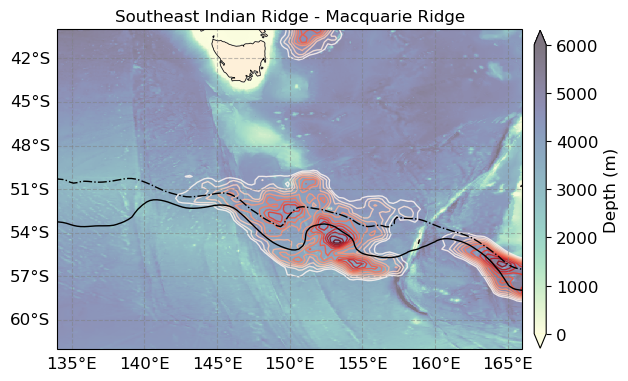

In [27]:
fig = plt.figure(figsize=(6,6))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent([134, 166, -62, -40], crs=ccrs.PlateCarree())

im = new_bathy.depth.plot(vmin = 0, vmax = 6000, 
                          cmap = cmocean.cm.deep, 
                          linestyles = '-', 
                          alpha = 0.6, 
                          linewidths = 0.8, 
                          add_colorbar = False, 
                          zorder = 0, 
                          transform=ccrs.PlateCarree())

### add EKE contours 
circumpolar_eke.plot.contour(levels = np.arange(0.04, 0.1, 0.005), linewidths = 1, cmap = 'Reds', alpha = 0.85, transform=ccrs.PlateCarree())
# circumpolar_ssh_std.plot.contour(levels = np.arange(0.12, 0.24, 0.01), linewidths = 1, cmap = 'magma_r', alpha = 0.85, transform=ccrs.PlateCarree())

### add cartopy features (land, coastlines, lat, lon)
func.map_properties(ax, t, ssh_insitu, contours = False)

### MDT contours: long-term mean positions of the Polar Front (PF; solid; -0.3 m) and northern branch of the Subantarctic Front (SAF; dashdot; 0 m) (Sallee et al. 2008; Auger et al. 2024)
circumpolar_mdt.adt.plot.contour(ax = ax, levels=[0], colors='k', linewidths = 1, linestyles = '-.', transform=ccrs.PlateCarree())
circumpolar_mdt.adt.plot.contour(ax = ax, levels=[-0.3], colors='k', linewidths = 1, linestyles = '-', transform=ccrs.PlateCarree())

ax.set_title(r'Southeast Indian Ridge - Macquarie Ridge', fontsize = 12)

cbar_ax = fig.add_axes([0.92, 0.23, 0.02, 0.53]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical', extend = 'both')
cb.set_label('Depth (m)')

In [18]:
# name = f'SEIR_bathy_map_withEKE.png'
# name = f'SEIR_bathy_map_with_SSHstd.png'
# fig.savefig(os.path.join(savepath, name), dpi = 500, bbox_inches='tight', pad_inches= 0.2)

### SatGEM maps

In [28]:
### load SatGEM dataset that includes velocities with Gaussian noise
satgem_sel = xr.open_dataset('data/satgem_SEIR_on_d_noisy.nc')
# satgem_sel = xr.open_dataset('data/satgem_SEIR_on_d_noise_exp.nc')

In [29]:
satgem_sel

<xarray.Dataset> Size: 2GB
Dimensions:      (time: 72, density: 60, latitude: 56, longitude: 129)
Coordinates:
  * latitude     (latitude) float32 224B -61.88 -61.62 -61.38 ... -48.38 -48.12
  * longitude    (longitude) float32 516B 133.9 134.1 134.4 ... 165.6 165.9
  * density      (density) float64 480B 27.0 27.01 27.02 ... 27.57 27.58 27.59
  * time         (time) datetime64[ns] 576B 2018-09-21 2018-09-22 ... 2018-12-01
Data variables:
    ugw          (time, density, latitude, longitude) float64 250MB ...
    vgw          (time, density, latitude, longitude) float64 250MB ...
    sal          (time, density, latitude, longitude) float64 250MB ...
    temp         (time, density, latitude, longitude) float64 250MB ...
    u_noise      (time, density, latitude, longitude) float64 250MB ...
    v_noise      (time, density, latitude, longitude) float64 250MB ...
    u_noise_2pc  (time, density, latitude, longitude) float64 250MB ...
    v_noise_2pc  (time, density, latitude, longitude) float64 250MB ...

In [30]:
### set date
t = '2018-11-20'
### set density level
d = 27.1

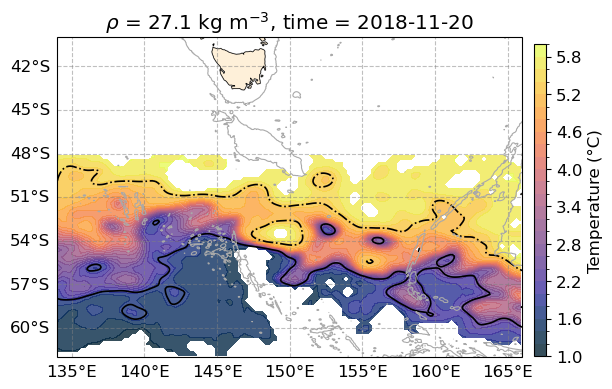

In [31]:
fig = plt.figure(figsize=(6,6))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent([134, 166, -62, -40], crs=ccrs.PlateCarree())

func.map_properties(ax, t, ssh_insitu, contours = True)

im =  satgem_sel.temp.sel(density = d, time = t, method= 'nearest').plot.contourf(cmap = cmocean.cm.thermal, levels = np.arange(1, 6.2, 0.2), 
                                                                         transform=ccrs.PlateCarree(), alpha = 0.8,
                                                                         add_colorbar= False)

new_bathy.depth.plot.contour(levels = [2500], colors = 'darkgray', linestyles = '-', linewidths = 0.8)

plt.title(r'$\rho$'+f' = {d}'+ r' kg m$^{-3}$'+ f', time = {t}')

cbar_ax = fig.add_axes([0.92, 0.23, 0.02, 0.52]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cb.set_label('Temperature (°C)')

In [32]:
# name = f'SEIR_temp_map_{t}.png'
# name = f'SEIR_temp_map_{t}_with_bathy.png'
# fig.savefig(os.path.join(savepath, name), dpi = 300, bbox_inches='tight', pad_inches= 0.2)

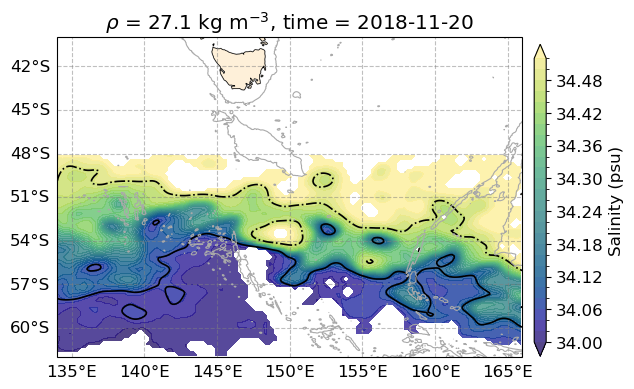

In [33]:
fig = plt.figure(figsize=(6,6))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent([134, 166, -62, -40], crs=ccrs.PlateCarree())

func.map_properties(ax, t, ssh_insitu, contours = True)

im =  satgem_sel.sal.sel(density = d, time = t, method= 'nearest').plot.contourf(cmap = cmocean.cm.haline, levels = np.arange(34, 34.52, 0.02), 
                                                                         transform=ccrs.PlateCarree(), alpha = 0.8, add_colorbar= False)

new_bathy.depth.plot.contour(levels = [2500], colors = 'darkgray', linestyles = '-', linewidths = 0.8)

plt.title(r'$\rho$'+f' = {d}'+ r' kg m$^{-3}$'+ f', time = {t}')

cbar_ax = fig.add_axes([0.92, 0.23, 0.02, 0.52]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cb.set_label('Salinity (psu)')

In [34]:
# name = f'SEIR_sal_map_{t}.png'
# name = f'SEIR_sal_map_{t}_with_bathy.png'
# fig.savefig(os.path.join(savepath, name), dpi = 300, bbox_inches='tight', pad_inches= 0.2)

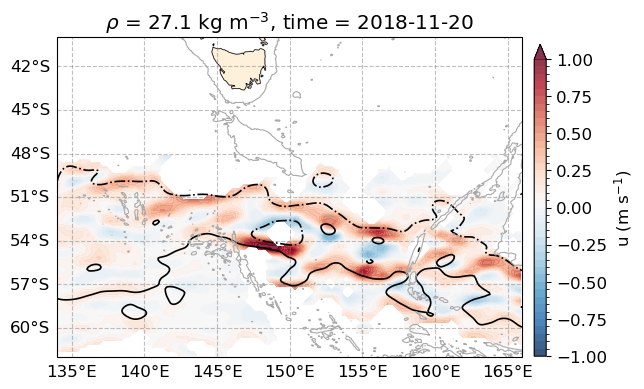

In [35]:
fig = plt.figure(figsize=(6,6))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent([134, 166, -62, -40], crs=ccrs.PlateCarree())

func.map_properties(ax, t, ssh_insitu, contours = True)

im =  satgem_sel.ugw.sel(density = d, time = t, method= 'nearest').plot.contourf(cmap = 'RdBu_r', levels = np.arange(-1, 1.05, 0.05), 
                                                                         transform=ccrs.PlateCarree(), alpha = 0.8, add_colorbar= False)

new_bathy.depth.plot.contour(levels = [2500], colors = 'darkgray', linestyles = '-', linewidths = 0.8)

plt.title(r'$\rho$'+f' = {d}'+ r' kg m$^{-3}$'+ f', time = {t}')

cbar_ax = fig.add_axes([0.92, 0.23, 0.02, 0.52]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cb.set_label(r'u (m s$^{-1}$)')

In [36]:
# name = f'SEIR_u_map_{t}.png'
# name = f'SEIR_u_map_{t}_with_bathy.png'
# fig.savefig(os.path.join(savepath, name), dpi = 300, bbox_inches='tight', pad_inches= 0.2)

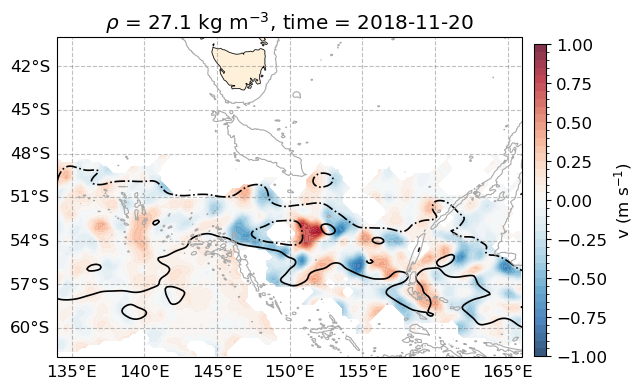

In [37]:
fig = plt.figure(figsize=(6,6))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent([134, 166, -62, -40], crs=ccrs.PlateCarree())

func.map_properties(ax, t, ssh_insitu, contours = True)

im =  satgem_sel.vgw.sel(density = d, time = t, method= 'nearest').plot.contourf(cmap = 'RdBu_r', levels = np.arange(-1, 1.05, 0.05), 
                                                                         transform=ccrs.PlateCarree(), alpha = 0.8,
                                                                         add_colorbar= False)

new_bathy.depth.plot.contour(levels = [2500], colors = 'darkgray', linestyles = '-', linewidths = 0.8)

plt.title(r'$\rho$'+f' = {d}'+ r' kg m$^{-3}$'+ f', time = {t}')

cbar_ax = fig.add_axes([0.92, 0.23, 0.02, 0.52]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cb.set_label(r'v (m s$^{-1}$)')

In [38]:
# name = f'SEIR_v_map_{t}.png'
# name = f'SEIR_v_map_{t}_with_bathy.png'
# fig.savefig(os.path.join(savepath, name), dpi = 300, bbox_inches='tight', pad_inches= 0.2)

-0.17812658391446767 0.19283295576107395


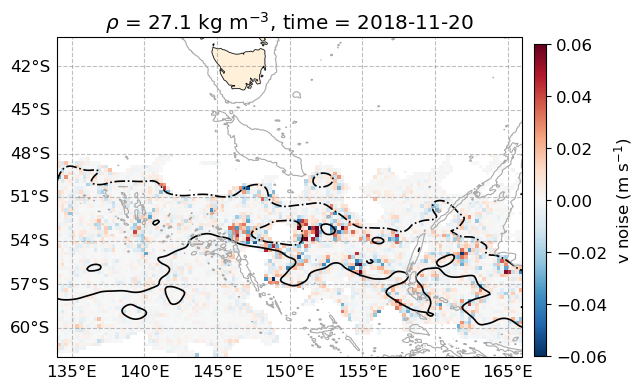

In [39]:
fig = plt.figure(figsize=(6,6))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent([134, 166, -62, -40], crs=ccrs.PlateCarree())

func.map_properties(ax, t, ssh_insitu, contours = True)

im =  (satgem_sel.vgw - satgem_sel.v_noise).sel(density = d, time = t, method= 'nearest').plot(cmap = 'RdBu_r',
                                                                                                  vmin = -0.06, vmax = 0.06, 
                                                                                                  transform=ccrs.PlateCarree(), 
                                                                                                  add_colorbar= False)

new_bathy.depth.plot.contour(levels = [2500], colors = 'darkgray', linestyles = '-', linewidths = 0.8)

plt.title(r'$\rho$'+f' = {d}'+r' kg m$^{-3}$'+ f', time = {t}')
 
cbar_ax = fig.add_axes([0.92, 0.23, 0.02, 0.52]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cb.set_label('v noise (m s$^{-1}$)')

noise_v = satgem_sel.vgw - satgem_sel.v_noise
print(np.nanmin(noise_v), np.nanmax(noise_v))

In [40]:
# name = f'SEIR_v_noise_map.png'
# name = f'SEIR_v_noise_map_with_bathy.png'
# fig.savefig(os.path.join(savepath, name), dpi = 300, bbox_inches='tight', pad_inches= 0.2)

-0.2035138093860398 0.19911913832339612


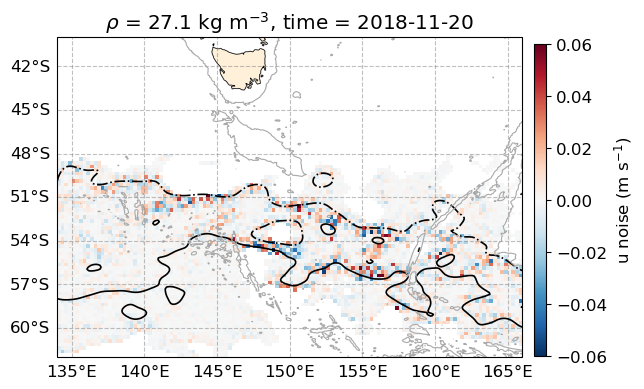

In [41]:
fig = plt.figure(figsize=(6,6))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent([134, 166, -62, -40], crs=ccrs.PlateCarree())

func.map_properties(ax, t, ssh_insitu, contours = True)

im =  (satgem_sel.ugw - satgem_sel.u_noise).sel(density = d, time = t, method= 'nearest').plot(cmap = 'RdBu_r',
                                                                                               vmin = -0.06, vmax = 0.06, 
                                                                                               transform=ccrs.PlateCarree(), 
                                                                                               add_colorbar= False)

new_bathy.depth.plot.contour(levels = [2500], colors = 'darkgray', linestyles = '-', linewidths = 0.8)
plt.title(r'$\rho$'+f' = {d}'+r' kg m$^{-3}$'+ f', time = {t}')

cbar_ax = fig.add_axes([0.92, 0.23, 0.02, 0.52]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cb.set_label('u noise (m s$^{-1}$)')

noise_u = satgem_sel.ugw - satgem_sel.u_noise
print(np.nanmin(noise_u), np.nanmax(noise_u))

In [42]:
# name = f'SEIR_u_noise_map.png'
# name = f'SEIR_u_noise_map_with_bathy.png'
# fig.savefig(os.path.join(savepath, name), dpi = 300, bbox_inches='tight', pad_inches= 0.2)

In [43]:
### time index
t0 = np.where(satgem_sel.time == satgem_sel.time.sel(time = t, method = 'nearest'))[0][0]

days = 10
start = satgem_sel.time[t0-days].data
end = satgem_sel.time[t0].data
print(start, end)

2018-11-10T00:00:00.000000000 2018-11-20T00:00:00.000000000


In [44]:
t_sel = satgem_sel.temp.sel(time = slice(start, end))
t_grad = func.sshGrad(t_sel)

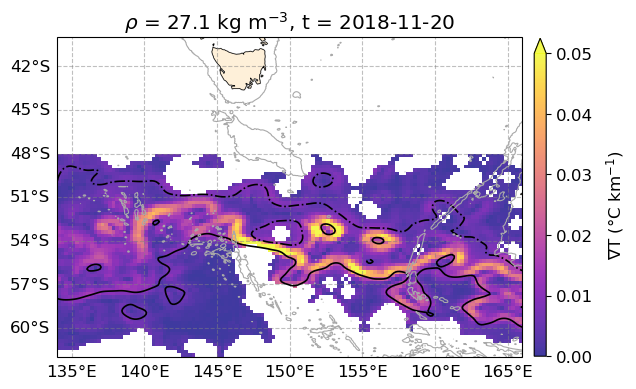

In [45]:
fig = plt.figure(figsize=(6,6))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent([134, 166, -62, -40], crs=ccrs.PlateCarree())

func.map_properties(ax, t, ssh_insitu)

im  = t_grad.sel(density = d, time = t, method = 'nearest').plot(cmap = 'plasma', 
                                                                vmin = 0, vmax = 0.05,
                                                                transform=ccrs.PlateCarree(), 
                                                                add_colorbar = False, 
                                                                alpha = 0.8, zorder = 0)

new_bathy.depth.plot.contour(levels = [2500], colors = 'darkgray', linestyles = '-', linewidths = 0.8)

plt.title(r'$\rho$ = ' + f'{d}' + r' kg m$^{-3}$, t = ' + t)

cbar_ax = fig.add_axes([0.92, 0.23, 0.02, 0.53]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical', extend = 'max')
cb.set_label(r'$\nabla$T (°C km$^{-1}$)', labelpad = 8)

In [46]:
# name = f'SEIR_Tgrad_map_{t}_with_bathy.png'
# fig.savefig(os.path.join(savepath, name), dpi = 300, bbox_inches='tight', pad_inches= 0.2)

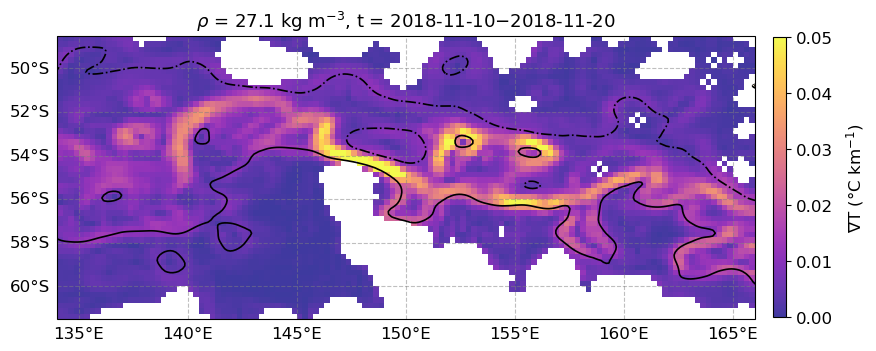

In [47]:
fig = plt.figure(figsize=(9, 7))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent([134, 166, -61.5, -48.5], crs=ccrs.PlateCarree())

func.map_properties(ax, slice(satgem_sel.time[t0-days], satgem_sel.time[t0]), ssh_insitu)

im  = t_grad.sel(density = d, method = 'nearest').mean(dim = 'time').plot(cmap = 'plasma', 
                                                                            vmin = 0, vmax = 0.05,
                                                                            transform=ccrs.PlateCarree(), 
                                                                            add_colorbar = False, 
                                                                            alpha = 0.8, zorder = 0)

start = str(satgem_sel.time[t0-days].data.astype('M8[D]'))
end = str(satgem_sel.time[t0].data.astype('M8[D]'))
plt.title(r'$\rho$ = ' + f'{d}' + r' kg m$^{-3}$, t = ' + start + '$-$' + end, fontsize = 13)

cbar_ax = fig.add_axes([0.92, 0.295, 0.015, 0.4]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cb.set_label(r'$\nabla$T (°C km$^{-1}$)', labelpad = 8)

In [48]:
# name = f'SEIR_Tgrad_map_{t}.png'
# name = f'SEIR_Tgrad_map_{t}_extended.png'
# fig.savefig(os.path.join(savepath, name), dpi = 300, bbox_inches='tight', pad_inches= 0.2)

In [111]:
u = satgem_sel.u_noise.sel(time = slice(start, end))
v = satgem_sel.v_noise.sel(time = slice(start, end))

speed = np.sqrt(u**2+v**2)
eke = func.EKE(u, v, u.time[0].values, u.time[-1].values)

mean u and v between 2018-11-10 and 2018-11-20


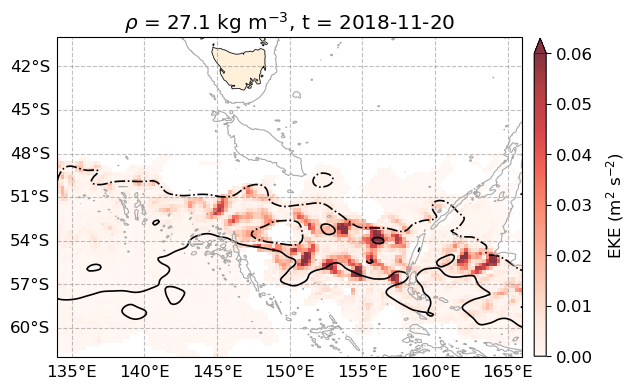

In [50]:
fig = plt.figure(figsize=(6,6))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent([134, 166, -62, -40], crs=ccrs.PlateCarree())

func.map_properties(ax, t, ssh_insitu)

im  = eke.sel(density = d, time = t, method = 'nearest').plot(cmap = 'Reds', 
                                                                vmin = 0, vmax = 0.06,
                                                                transform=ccrs.PlateCarree(), 
                                                                add_colorbar = False, 
                                                                alpha = 0.8, zorder = 0)

new_bathy.depth.plot.contour(levels = [2500], colors = 'darkgray', linestyles = '-', linewidths = 0.8)

start = str(satgem_sel.time[t0-days].data.astype('M8[D]'))
end = str(satgem_sel.time[t0].data.astype('M8[D]'))
plt.title(r'$\rho$ = ' + f'{d}' + r' kg m$^{-3}$, t = ' + t)

cbar_ax = fig.add_axes([0.92, 0.23, 0.02, 0.53]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical', extend = 'max')
cb.set_label(r'EKE (m$^{2}$ s$^{-2}$)', labelpad = 8)

In [51]:
# name = f'SEIR_EKE_map_{t}_with_bathy.png'
# fig.savefig(os.path.join(savepath, name), dpi = 300, bbox_inches='tight', pad_inches= 0.2)

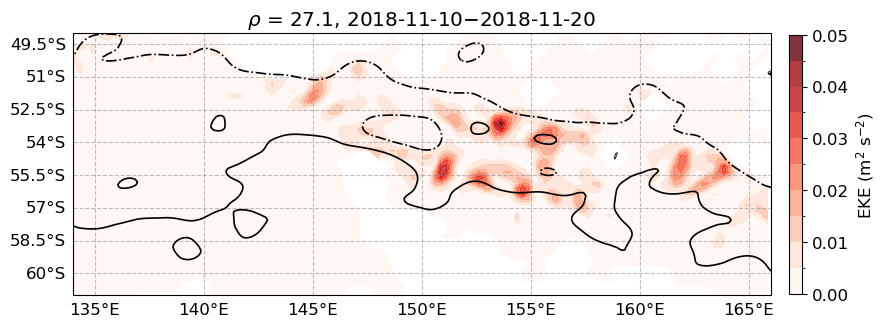

In [53]:
fig = plt.figure(figsize=(9, 7))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent([134, 166, -61, -49], crs=ccrs.PlateCarree())

func.map_properties(ax, slice(satgem_sel.time[t0-days], satgem_sel.time[t0]), ssh_insitu)

im  = eke.sel(density = 27.1, method = 'nearest').mean(dim = 'time').plot.contourf(cmap = 'Reds', 
                                                                                levels = np.arange(0, 0.055, 0.005),
                                                                                transform=ccrs.PlateCarree(), 
                                                                                add_colorbar = False, 
                                                                                alpha = 0.8, zorder = 0)

start = str(satgem_sel.time[t0-days].data.astype('M8[D]'))
end = str(satgem_sel.time[t0].data.astype('M8[D]'))
plt.title(r'$\rho$ = 27.1, ' + start + '$-$' + end)

cbar_ax = fig.add_axes([0.92, 0.31, 0.015, 0.37]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cb.set_label(r'EKE (m$^{2}$ s$^{-2}$)')

In [54]:
# name = f'SEIR_EKE_map_{t}_extended.png'
# fig.savefig(os.path.join(savepath, name), dpi = 300, bbox_inches='tight', pad_inches= 0.2)

### Ocean Parcels setup 

In [55]:
# variables = {"U": "ugw", "V": "vgw", "T": "temp", "S": "sal"}
variables = {"U": "u_noise", "V": "v_noise", "T": "temp", "S": "sal"}

### other noise experiments
# variables = {"U": "u_noise_2pc", "V": "v_noise_2pc", "T": "temp", "S": "sal"}
# variables = {"U": "smooth_noise_u", "V": "smooth_noise_v", "T": "temp", "S": "sal"}
# variables = {"U": "smooth_noise_u_exp", "V": "smooth_noise_v_exp", "T": "temp", "S": "sal"}
# variables = {"U": "smooth_noise_u_perturb", "V": "smooth_noise_v_perturb", "T": "temp", "S": "sal"}

dimensions = {
    "U": {"time": "time", "depth": "density", "lat": "latitude", "lon": "longitude"},
    "V": {"time": "time", "depth": "density", "lat": "latitude", "lon": "longitude"},
    "T": {"time": "time", "depth": "density", "lat": "latitude", "lon": "longitude"},
    "S": {"time": "time", "depth": "density", "lat": "latitude", "lon": "longitude"},
}

In [56]:
fieldset = FieldSet.from_xarray_dataset(satgem_sel, variables, dimensions,
                                        interp_method={"U": "partialslip",
                                                       "V": "partialslip",
                                                       "T" : "linear_invdist_land_tracer",
                                                       "S" : "linear_invdist_land_tracer",})

In [57]:
### underlying SatGEM fields to be sampled along the particle trajectories 
SampleParticle = JITParticle.add_variables(
    ["temp", "sal",
     Variable("U", dtype=np.float32, initial=np.nan),
     Variable("V", dtype=np.float32, initial=np.nan)])

### Meridional section of particles

In [58]:
### set intial time to release particles
t = '2018-11-20'
t0 = np.where(satgem_sel.time == satgem_sel.time.sel(time = t, method = 'nearest'))[0][0]

In [59]:
### release longitide
lon0 = 153

In [60]:
### particle release coordinates (lat and lon)
y = np.arange(-58, -50.95, 0.1)
x = np.tile(lon0, y.shape)

In [61]:
### set density range
dens_interval = 0.01
dens = np.arange(27.1, 27.5, dens_interval)

In [62]:
### repeat to 2D 
xx = np.repeat(x[:, np.newaxis], len(dens), axis=1)
yy = np.repeat(y[:, np.newaxis], len(dens), axis=1)
dens_2d = np.repeat(dens[np.newaxis, :], xx.shape[0], axis=0)

In [63]:
n_particles = len(xx.flatten())
time = np.tile(satgem_sel.time[t0].data, n_particles)

In [64]:
### advection time
n_days = 15

lons = xx
lats = yy

In [65]:
pc = 5 # noise percentage (of velocities)
timestep = 6 #hours

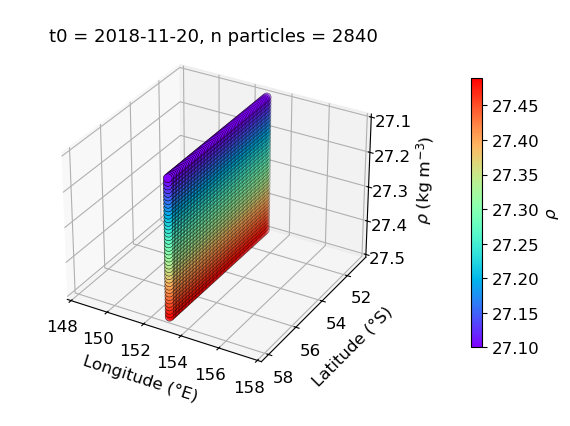

In [66]:
fig = plt.figure(figsize=(7, 7))
ax = plt.axes(projection='3d')

im = ax.scatter(xx.flatten(), yy.flatten(), 
                zs=dens_2d.flatten(), 
                c = dens_2d.flatten(), 
                cmap='rainbow',
                edgecolor="k", 
                zorder=2, 
                linewidth = 0.4, 
                s=40)

plt.colorbar(im, label=r"$\rho$", aspect = 25, shrink = 0.5, pad = 0.1)
    
# ax.set_ylim(y[0]-0.15, y[-1]+0.15)
ax.set_xlim(148, 158)
ax.set_yticks(np.arange(-58, -50, 2))
ax.set_yticklabels(np.arange(58, 50, -2))
ax.set_zlim(27.1, 27.5)
ax.set_zticks(np.arange(27.1, 27.6, 0.1))
ax.invert_zaxis()

plt.xlabel('Longitude (°E)', labelpad  = 8)
plt.ylabel('Latitude (°S)', labelpad  = 8)
ax.set_zlabel(r'$\rho$ (kg m$^{-3}$)', labelpad = 8)

ax.set_aspect('equal')

plt.title(f't0 = {t}' + f', n particles = {n_particles}', y = 0.98, fontsize = 13)
ax.set_box_aspect(None, zoom=0.85)

In [67]:
# name = f'meridional_particle_columns.png'
# fig.savefig(os.path.join(savepath, name), dpi = 300, bbox_inches='tight', pad_inches= 0.2)

### Run particle advection

In [68]:
# pset = ParticleSet(
#     fieldset=fieldset, pclass=SampleParticle, lon=lons, 
#     lat=lats, time=time, depth = dens_2d
# )

# filename = f'output/SEIR/MeridionalSection_{lon0}_{n_days}days_{pc}noise_{t}.zarr'
# # filename = f'output/SEIR/MeridionalSection_{lon0}_{n_days}days_{pc}noise_smooth_{t}.zarr'
# # filename = f'output/SEIR/MeridionalSection_{lon0}_{n_days}days_{pc}noise_smooth_exp_{t}.zarr'
# # filename = f'output/SEIR/MeridionalSection_{lon0}_{n_days}days_{pc}noise_smooth_perturb_{t}.zarr'

# output_file = pset.ParticleFile(name=filename, outputdt=timedelta(hours=timestep))

# # set dt to negative for backward advection
# dt = -timedelta(hours=timestep)

# pset.execute(
#     [AdvectionRK4, SampleTS, SampleUV, StuckParticles],
#     runtime=timedelta(days=n_days),
#     dt=dt,
#     output_file=output_file,
# )

#### Load saved particle advection file

In [69]:
## noise percentage
pc = 5

In [70]:
filename = f'output/SEIR/MeridionalSection_{lon0}_{n_days}days_{pc}noise_{t}.zarr'

### other noise experiments
# filename = f'output/SEIR/MeridionalSection_{lon0}_{n_days}days_{pc}noise_smooth_{t}.zarr'
# filename = f'output/SEIR/MeridionalSection_{lon0}_{n_days}days_{pc}noise_smooth_exp_{t}.zarr'
# filename = f'output/SEIR/MeridionalSection_{lon0}_{n_days}days_{pc}noise_smooth_perturb_{t}.zarr'

In [71]:
ds_out = xr.open_zarr(filename)
df = ds_out.to_dataframe()

### Plot results

In [72]:
### after 10 days
days = 10
sample_interval = int(24/timestep)
t_ind = days*sample_interval

In [73]:
start = satgem_sel.time[t0-days].data
end = satgem_sel.time[t0].data
print('release time t0: ', end)
print('t0 -10 days: ', start)

release time t0:  2018-11-20T00:00:00.000000000
t0 -10 days:  2018-11-10T00:00:00.000000000


In [74]:
### calculate EKE from the SatGEM velocities on the 27.1 isopycnal, for the 10 day advection period.
d = 27.1
# u = satgem_sel.u_noise.sel(density = d, method = 'nearest').sel(time = slice(start, end))
# v = satgem_sel.v_noise.sel(density = d, method = 'nearest').sel(time = slice(start, end))
# eke = func.EKE(u, v, u.time[0].values, u.time[-1].values)

mean u and v between 2018-11-10 and 2018-11-20


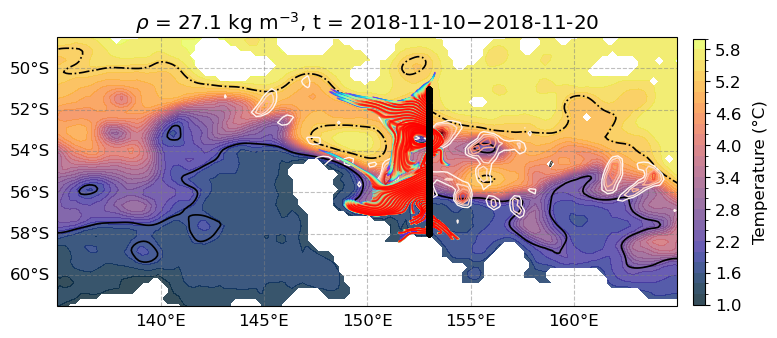

In [75]:
fig = plt.figure(figsize=(8, 7))
ax = plt.subplot(projection=ccrs.PlateCarree())
ax.set_extent([135, 165, -61.5, -48.5], crs=ccrs.PlateCarree())

n = len(dens)
colors = plt.cm.rainbow(np.linspace(0,1,n))

### plot PF and nSAF locations (ADT contours)
func.map_properties(ax, slice(satgem_sel.time[t0-days], satgem_sel.time[t0]), ssh_insitu)

### plot particle trajectories (rainbow)
i = 0
for di in dens:
    df_sel = df.loc[df['z'] == di]
    im = plt.plot(df_sel.to_xarray().lon.T[0:t_ind+1], df_sel.to_xarray().lat.T[0:t_ind+1], 
                  c = colors[i], alpha = 0.6, linewidth = 0.9, 
                  transform=ccrs.PlateCarree(), zorder = 10)
    i +=1

ax.legend_ = None
### plot particle release locations (black)
plt.plot(ds_out.lon[:, 0], ds_out.lat[:, 0], "o", ms = 3, c = 'k', alpha=0.5, transform=ccrs.PlateCarree(), zorder = 12)

meanT = satgem_sel.temp.sel(time = slice(satgem_sel.time[t0-days], satgem_sel.time[t0])).mean('time')
im = meanT.sel(density = d, method = 'nearest').plot.contourf(cmap = cmocean.cm.thermal, 
                                                              levels = np.arange(1, 6.2, 0.2), 
                                                              transform=ccrs.PlateCarree(), 
                                                              add_colorbar = False, 
                                                              alpha = 0.8, zorder = 0)

### plot EKE contours (red)
mean_eke = eke.sel(density = d, method = 'nearest').mean(dim  = 'time')
mean_eke.plot.contour(levels = np.arange(0.01, 0.05, 0.005), 
                      cmap = 'Reds', linewidths = 1, zorder = 2,
                      transform=ccrs.PlateCarree(), add_colorbar = False)


start = str(satgem_sel.time[t0-days].data.astype('M8[D]'))
end = str(satgem_sel.time[t0].data.astype('M8[D]'))
plt.title(r'$\rho$ = ' + f'{d}' + r' kg m$^{-3}$, t = ' + start + '$-$' + end)

cbar_ax = fig.add_axes([0.92, 0.305, 0.015, 0.38]) 
cb = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cb.set_label('Temperature (°C)', labelpad = 8)
# cb.set_label('$\overline{EKE}$')

In [76]:
# name = f'SEIR_particle_map_{lon0}_{t}.png'
# fig.savefig(os.path.join(savepath, name), dpi = 300, bbox_inches='tight', pad_inches= 0.2)

### Extract T-S properties

In [77]:
col_idx = np.arange(0, len(ds_out.trajectory), len(dens))
### T-S at particle origin locations (e.g. -10 days)
originT, originS = func.origin_TS(ds_out, col_idx, t_ind, dens)

In [78]:
### T-S at particle release locations (e.g. 0 days)
seed_temp = ds_out.temp[:, 0]
seed_sal = ds_out.sal[:, 0]

In [79]:
### density contours for T-S diagram 
ti, si, dens_contour = func.tsDensContour(seed_sal, seed_temp)

In [80]:
## vertical rolling mean

# originT = originT.rolling(potential_density = 3, center = True, min_periods = 2).mean()
# originS = originS.rolling(potential_density = 3, center = True, min_periods = 2).mean()

#### T-S diagram

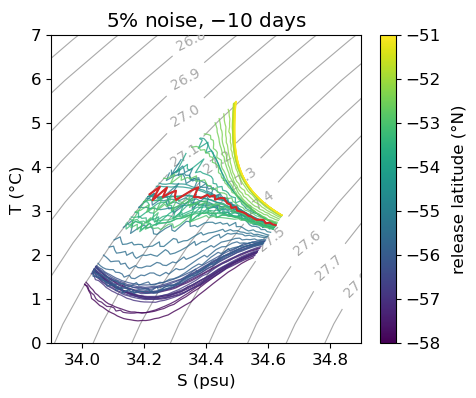

In [81]:
fig, ax = plt.subplots(figsize = (5, 4))

### draw density contours
CS = ax.contour(si, ti, dens_contour, levels = np.arange(26.4, 27.9, 0.1), linewidths = 0.8, colors='darkgrey')
plt.clabel(CS, inline=1, fontsize=10, fmt = '%1.1f')

n = len(y)
colors = plt.cm.viridis(np.linspace(0,1,n))

### plot reconstructed profiles
k = 0
for prof in range(len(originS)): 
    im = ax.plot(originS[prof], originT[prof], c= colors[k], linewidth = 0.9, alpha = 0.8, zorder= 20)
    k+=1

### highlight a particlar profile in red (lt = latitude of particle release column)
lt = -53.8 #-55.2 #
ax.plot(originS.sel(latitude = lt, method = 'nearest'), originT.sel(latitude = lt, method = 'nearest'), c = 'tab:red', zorder = 100)

plt.xlim(33.9,34.9)
plt.ylim(0, 7)
plt.ylabel('T (°C)')
plt.xlabel('S (psu)')

### add colourbar
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=min(y), vmax=max(y)))
cb = plt.colorbar(sm, ax=ax)
cb.set_label(label = 'release latitude (°N)', labelpad = 8)

plt.title(f'{pc}% noise, $-${days} days')
# plt.title(f'longitude: {lon0}°E \n {pc}% noise, $-${days} days', fontsize = 12)
# plt.title(f'longitude: {lon0}°E \n {pc}% noise smoothed, $-${days} days', fontsize = 12)
# plt.title(f'longitude: {lon0}°E \n {pc}% noise smoothed exp, $-${days} days', fontsize = 12)
# plt.title(f'longitude: {lon0}°E \n {pc}% noise smoothed perturb, $-${days} days', fontsize = 12)
# plt.title(f'longitude: {lon0}°E, latitude: {lt}°N', fontsize = 12)
plt.show()

In [82]:
# name = f'SEIR_TS_{lon0}_{t}.png'
# name = f'SEIR_TS_{lon0}_{t}_{pc}noise_smoothed.png'
# name = f'SEIR_TS_{lon0}_{t}_{pc}noise_smoothed_exp.png'

# name = f'SEIR_TS_{lon0}_{lt}_{t}.png'
# # name = f'SEIR_TS_{lon0}_{t}_release_location.png'
# fig.savefig(os.path.join(savepath, name), dpi = 300, bbox_inches='tight', pad_inches= 0.2)

#### Individual particle column 3D plot

In [83]:
### index of highlighted profile
i = np.where(ds_out.lat[:, 0] == lt)[0][0]

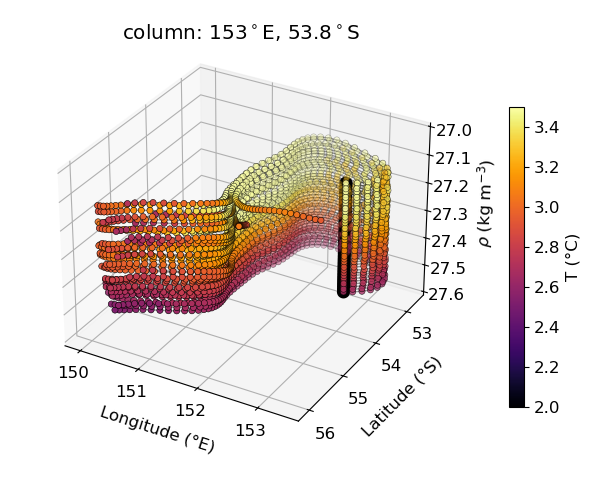

In [84]:
fig = plt.figure(figsize=(8,6))
ax = plt.axes(projection='3d') # computed_zorder=False)

### loop through density levels
for d in range(i, i+len(dens)):
    
    ### release location
    ax.scatter(ds_out.lon[d, 0], ds_out.lat[d, 0], zs = ds_out.z[d, 0],  facecolors = 'none', linewidth = 5, edgecolor = 'k', s=20)
    
    ### particle locations
    ax.plot(ds_out.lon[d, :].T, ds_out.lat[d, :].T, zs = ds_out.z[d, :].T, c = 'k', linewidth = 1, alpha = 0.4)

    ### colour by underlying SatGEM temperature properties
    im = ax.scatter(ds_out.lon[d, :].T, ds_out.lat[d, :].T, zs = ds_out.z[d, :].T, 
                    c = ds_out.temp[d, :].T, cmap=plt.cm.inferno, 
                    norm=mpl.colors.Normalize(vmin=2, vmax=3.5), 
                    edgecolor="k", zorder=2, linewidth=0.4, s=20)
    
    ### origin location
    # ax.scatter(ds_out.lon[d, -1], ds_out.lat[d, -1], zs = ds_out.z[d, -1], marker = 'x', facecolors = 'k', s=20)

# ax.scatter(ds_out.lon[i, 0], ds_out.lat[i, 0], zs = ds_out.z[i, 0], marker = '*', facecolors = 'w', edgecolors = 'k', linewidths = 0.02, s=50)

ax.set_zlim(27, 27.6)
ax.invert_zaxis()

ax.set_xticks(np.arange(150, 154, 1)) #np.arange(146, 154, 2) #np.arange(141, 145, 1)
ax.tick_params(axis='x', which='major', pad=1)

ax.set_yticks(np.arange(-56, -52, 1)) #np.arange(-54, -50, 1)
ax.set_yticklabels(np.arange(56, 52,-1)) #np.arange(54, 50,-1)
ax.set_box_aspect(aspect=None, zoom=0.9)

ax.set_ylabel('Latitude (°S)', labelpad = 8)
ax.set_xlabel('Longitude (°E)', labelpad = 6)
ax.set_zlabel(r'$\rho$ (kg m$^{-3}$)', labelpad = 8)

plt.colorbar(im, label="T (°C)", aspect = 20, shrink = 0.65, pad = 0.06, anchor = (0, 0.4))
plt.title(f'column: {ds_out.lon[i, 0].values:.0f}$^\circ$E, {abs(ds_out.lat[i, 0]).values:.1f}$^\circ$S', y = 1)
ax.view_init(elev=30, azim=-60)
# plt.tight_layout()
plt.show()

In [85]:
# name = f'SEIR_col_{lon0}_{lt}_{t}.png'
# name = f'SEIR_col_{lon0}_{lt}_{t}_simple.png'
# fig.savefig(os.path.join(savepath, name), dpi = 500, bbox_inches='tight', pad_inches= 0.2)

In [86]:
np.where(ds_out.time[i, :].values == np.datetime64('2018-11-10'))[0]

array([40])

#### T-S evolution 

In [87]:
### set time indices (e.g. for 0, -5, -10 and -15 days) 
day_ind = [0, 20, 40, -1]
colors = plt.cm.plasma(np.linspace(0,1,len(day_ind)+1))

Text(0.5, 1.0, 'column: 153$^\\circ$E, 53.8$^\\circ$S')

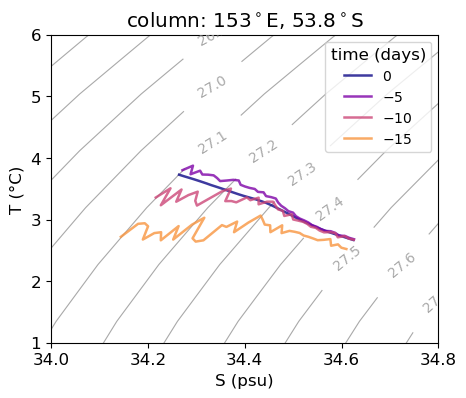

In [88]:
fig, ax = plt.subplots(figsize = (5, 4))

### draw density contours
CS = ax.contour(si, ti, dens_contour, levels = np.arange(26.4, 27.9, 0.1), linewidths = 0.8, colors='darkgrey')
plt.clabel(CS, inline=1, fontsize=10, fmt = '%1.1f')

### plot reconstructed T-S profiles at different time steps
k = 0
for day in day_ind:
    plt.plot(ds_out.sal[i:i+len(dens), day], ds_out.temp[i:i+len(dens), day], linewidth = 1.8, color = colors[k], alpha = 0.8)
    k+=1

plt.legend([r'0', r'$-$5', r'$-$10', r'$-$15'], fontsize = 10, title = 'time (days)', loc = 'upper right')
plt.xlim(34,34.8)
plt.ylim(1, 6)
plt.ylabel('T (°C)')
plt.xlabel('S (psu)')

plt.title(f'column: {ds_out.lon[i, 0].values:.0f}$^\circ$E, {abs(ds_out.lat[i, 0]).values:.1f}$^\circ$S')

In [89]:
# name = f'SEIR_col_{lon0}_{lt}_{t}_evolution.png'
# fig.savefig(os.path.join(savepath, name), dpi = 500, bbox_inches='tight', pad_inches= 0.2)

### Simple 3D particle plot

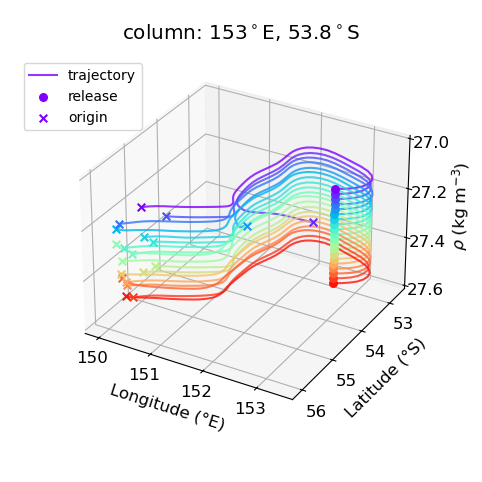

In [90]:
fig = plt.figure(figsize=(8,6))
ax = plt.axes(projection='3d')

n = len(dens)
colors = plt.cm.rainbow(np.linspace(0,1,n))

### plot particle trajectories every 0.02 kg/m3
k = 0
for d in np.arange(i, i+len(dens),2):
    ax.plot(ds_out.lon[d, :].T, ds_out.lat[d, :].T, zs=ds_out.z[d, :].T, zdir='z', c = colors[k], alpha = 0.8)
    ax.scatter(ds_out.lon[d, 0], ds_out.lat[d, 0], zs=ds_out.z[d, 0], color = colors[k], zdir='z', s = 30)
    ax.scatter(ds_out.lon[d, -1], ds_out.lat[d, -1], zs=ds_out.z[d, -1], color = colors[k], zdir='z', s = 30, marker = 'x')
    k+=2

ax.legend(['trajectory', 'release', 'origin'], fontsize = 10, bbox_to_anchor=[0.3, 0.9])

ax.set_zlim(27, 27.6)
ax.set_zticks(np.arange(27, 27.6, 0.2))
ax.invert_zaxis()

ax.set_xticks(np.arange(150, 154, 1))
ax.tick_params(axis='x', which='major', pad=1)

ax.set_yticks(np.arange(-56, -52, 1))
ax.set_yticklabels(np.arange(56, 52,-1))

ax.set_ylabel('Latitude (°S)', labelpad = 8)
ax.set_xlabel('Longitude (°E)', labelpad = 6)
ax.set_zlabel(r'$\rho$ (kg m$^{-3}$)', labelpad = 8)

ax.set_box_aspect(aspect=None, zoom=0.8)
plt.title(f'column: {ds_out.lon[i, 0].values:.0f}$^\circ$E, {abs(ds_out.lat[i, 0]).values:.1f}$^\circ$S', y = 1)

ax.view_init(elev=30, azim=-60)
plt.show()

In [91]:
# name = f'SEIR_col_{lon0}_{lt}_{t}_simple.png'
# fig.savefig(os.path.join(savepath, name), dpi = 500, bbox_inches='tight', pad_inches= 0.2)

### Calculate DSC from reconstructed T-S profiles 

In [92]:
dsc = func.DSC(originT, originS, dens_2d, vert_smooth = False, x_smooth = False)
dsc['latitude'] = y

Text(0.5, 1.0, 'longitude: 153°E')

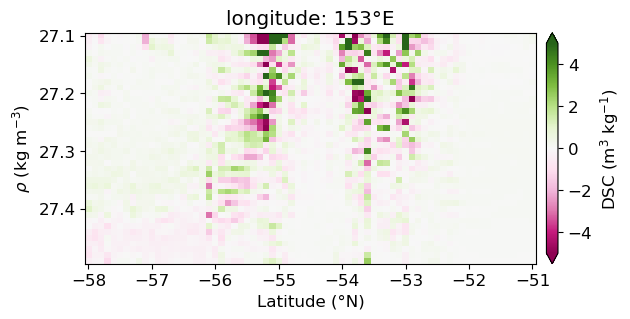

In [93]:
fig, ax = plt.subplots(figsize=(7, 3))
dsc.plot(x = 'latitude', cmap = 'PiYG', vmin = -5, vmax = 5, 
         cbar_kwargs = dict(label = r'DSC (m$^{3}$ kg$^{-1}$)', pad = 0.02))

ax.invert_yaxis()
ax.set_ylabel(r'$\rho$ (kg m$^{-3}$)')
plt.xlabel('Latitude (°N)')
plt.title(f'longitude: {lon0}°E')

In [94]:
### open saved dataset
ds = xr.open_dataset(f'/g/data/jk72/mj0995/summary_stats/SEIR_MeridionalSection_{lon0}_{t}_10days.nc')

Text(0.5, 1.0, 'longitude: 153°E')

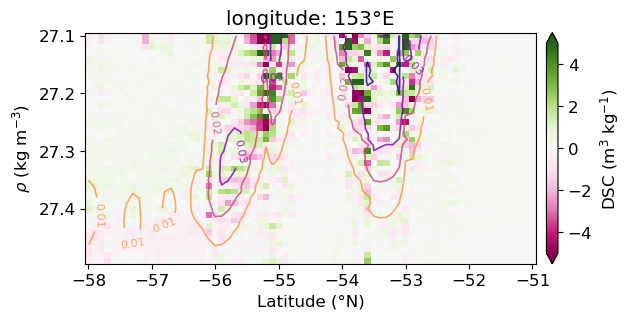

In [95]:
### plot DSC with T gradient contours
fig, ax = plt.subplots(figsize=(7, 3))
ds.DSC.plot(x = 'latitude', cmap = 'PiYG', vmin = -5, vmax = 5, cbar_kwargs = dict(label = r'DSC (m$^{3}$ kg$^{-1}$)', pad = 0.02))

## isopycnal temperature gradients from SatGEM-2 averaged along the particle trajectory
CS = ds.T_grad.plot.contour(x = 'latitude', cmap = 'plasma_r', levels = np.arange(0, 0.05, 0.01), linewidths = 1.2, alpha = 0.8)
plt.clabel(CS, np.arange(0, 0.04, 0.01), fontsize = 8)

ax.invert_yaxis()
ax.set_ylabel(r'$\rho$ (kg m$^{-3}$)')
plt.xlabel('Latitude (°N)')
plt.title(f'longitude: {lon0}°E')

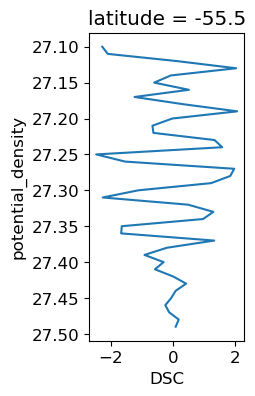

In [96]:
### select a profile (e.g. latitude = -55.5)
fig, ax = plt.subplots(figsize = (2, 4))
ds.DSC.sel(latitude=-55.5, method = 'nearest').plot(y = 'potential_density')
ax.invert_yaxis()

In [97]:
# name = f'SEIR_DSC_{lon0}_{t}.png'
# fig.savefig(os.path.join(savepath, name), dpi = 300, bbox_inches='tight', pad_inches= 0.2)

Text(0.5, 1.0, 'Depth-averaged DSC magnitude')

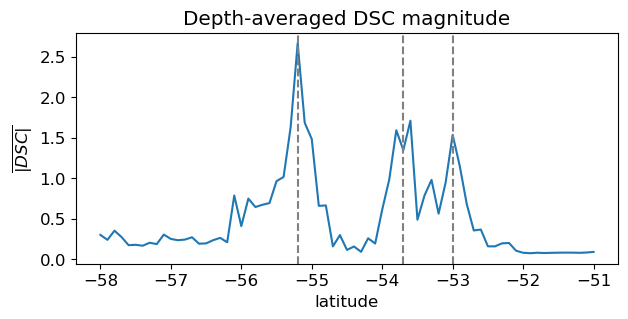

In [98]:
### plot depth-averaged DSC magnitude
fig, ax = plt.subplots(figsize=(7, 3))
abs(dsc).mean(dim = 'potential_density').plot()
plt.axvline(x = -55.2, c = 'grey', linestyle = '--')
plt.axvline(x = -53.7, c = 'grey', linestyle = '--')
plt.axvline(x = -53, c = 'grey', linestyle = '--')
plt.ylabel('$\overline{|DSC|}$')
plt.title('Depth-averaged DSC magnitude')

### Trajectory statistics

In [99]:
days = 10
t_ind = 40

In [100]:
start = satgem_sel.time[t0-days].data
end = satgem_sel.time[t0].data
print(start, end)

2018-11-10T00:00:00.000000000 2018-11-20T00:00:00.000000000


#### Cumulative distance travelled 

In [101]:
dist_travelled = func.distance_travelled(ds_out, col_idx, t_ind, dens)

Text(0, 0.5, 'cumulative distance (km)')

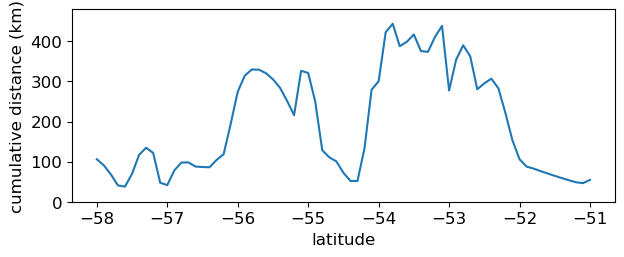

In [102]:
fig, ax = plt.subplots(figsize = (7,2.5))
dist_travelled.mean(dim = 'potential_density').plot()
plt.ylim(0, 480)
plt.ylabel('cumulative distance (km)')

In [103]:
# ds = xr.open_dataset(f'summary_stats/SEIR_MeridionalSection_{lon0}_{t}_{days}days.nc')
# ds['cum_dist'] = xr.DataArray(dist_travelled.data, dims = ds.T_grad.dims)
# ds.cum_dist.attrs = {"description": "cumulative distance travelled by each particle (km)"}
# ds.to_netcdf(f'summary_stats/SEIR_MeridionalSection_{lon0}_{t}_{days}days_v2.nc')

#### DSC generation: number of days for depth-averaged DSC magnitude to exceed 1 m$^{3}$ kg$^{-1}$

In [104]:
dsc_gen = func.all_cols_dsc_generation(ds_out, col_idx, t_ind, dens)
dsc_gen = xr.DataArray(dsc_gen, dims = dsc.dims, coords = dsc.coords)

In [105]:
# fig, ax = plt.subplots(figsize=(7, 2.5))
# dsc_gen.plot(x = 'latitude', cmap = 'plasma_r', vmin = 0, vmax = 15, 
#             cbar_kwargs = dict(label = 'n_days'))

# plt.title('Days for depth-avg DSC magnitude to reach > 1 m^3/kg', fontsize = 10)

#### Average isopycnal temperature gradient along the particle trajectories

In [106]:
avg_t_grad = func.col_trajectory_avg(ds_out, t_grad, col_idx, t_ind, dens)
avg_t_grad = xr.DataArray(avg_t_grad, dims = dsc.dims, coords = dsc.coords)

Text(0.5, 1.0, 'trajectory-averaged $\\nabla$T')

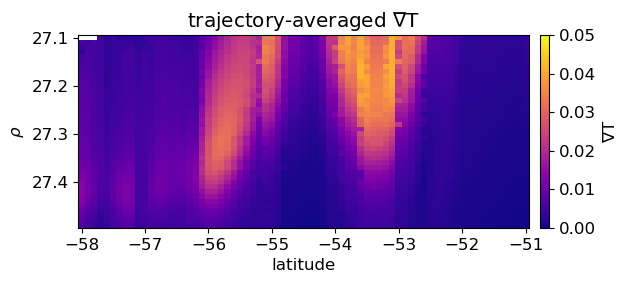

In [107]:
fig, ax = plt.subplots(figsize=(7, 2.5))
avg_t_grad.plot(x = 'latitude', cmap = 'plasma', vmin = 0, vmax = 0.05, cbar_kwargs = dict(label = r'$\nabla$T', pad = 0.02))

ax.invert_yaxis()
ax.set_ylabel(r'$\rho$')
plt.title(r'trajectory-averaged $\nabla$T')

#### Average EKE along the particle trajectories

In [114]:
avg_eke = func.col_trajectory_avg(ds_out, eke, col_idx, t_ind, dens)
avg_eke = xr.DataArray(avg_eke, dims = dsc.dims, coords = dsc.coords)

Text(0.5, 1.0, 'trajectory-averaged EKE')

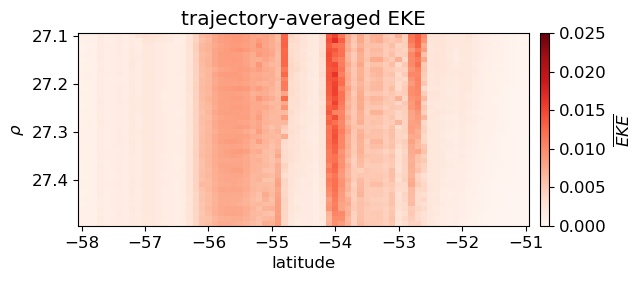

In [115]:
fig, ax = plt.subplots(figsize=(7, 2.5))
avg_eke.plot(x = 'latitude', cmap = 'Reds', vmin = 0, vmax = 0.025, cbar_kwargs = dict(label = r'$\overline{EKE}$', pad = 0.02))

ax.invert_yaxis()
ax.set_ylabel(r'$\rho$')
plt.title(r'trajectory-averaged EKE')

#### Average speed along the particle trajectories

In [ ]:
avg_speed = func.col_trajectory_avg(ds_out, speed, col_idx, t_ind, dens)
avg_speed = xr.DataArray(avg_speed, dims = dsc.dims, coords = dsc.coords)

In [ ]:
fig, ax = plt.subplots(figsize=(7, 2.5))
avg_speed.plot(x = 'latitude', cmap = 'viridis', vmin = 0, vmax = 0.8, 
         cbar_kwargs = dict(label = r'$\overline{speed}$', pad = 0.02))
ax.invert_yaxis()
ax.set_ylabel(r'$\rho$')
plt.title(r'trajectory-averaged speed')

#### Save summary statistics to netcdf

In [ ]:
print(f'{lon0}E')
print(t, f'{days} days')

In [ ]:
# ds = avg_t_grad.to_dataset(name="T_grad")
# ds.T_grad.attrs = {"description": "horizontal temperature gradient averaged along the particle trajectories"}

# ds["DSC"] = dsc
# ds.DSC.attrs = {"description": "diapycnal spiciness curvatrue (dsc) calculated using particle origin T and S"}

# ds["EKE"] = avg_eke
# ds.EKE.attrs = {"description": "average EKE along the particle trajectories"}

# ds['dsc_generation'] = dsc_gen
# ds.dsc_generation.attrs = {"description": "number of days for depth-avg DSC magnitude to reach 1 m$^{3}$ kg$^{-1}$"}

# ds['speed'] = avg_speed
# ds.speed.attrs = {"description": "Average current speed experienced by the particles along their trajectories"}

# ds['cum_dist'] = xr.DataArray(dist_travelled.data, dims = ds.T_grad.dims)
# ds.cum_dist.attrs = {"description": "cumulative distance travelled by each particle (km)"}

# ds.attrs = {"description": f"Meridional section of particles released at {lon0}E on {t} and advected backward-in-time for {days} days"}

In [ ]:
# ds.to_netcdf(f'summary_stats/SEIR_MeridionalSection_{lon0}_{t}_{days}days.nc')